<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%201/Econ_5200_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
student_basket = [
    {'Item': 'Chick-Fil-A Spicy Delxue','Price_2016': 4.05,'Price_2026': 6.85},
    {'Item': 'Basic Netflix Subscription', 'Price_2016': 9.99,'Price_2026': 17.99},
    {'Item': 'Northeastern Total Costs', 'Price_2016': 65503,'Price_2026': 94137},
    {'Item': 'Honda Civic', 'Price_2016': 18640,'Price_2026':25745}
]

In [116]:
def calculate_inflation(base, current):
    return ((current - base) / base) * 100

for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2026'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

Chick-Fil-A Spicy Delxue: 69.14% Inflation
Basic Netflix Subscription: 80.08% Inflation
Northeastern Total Costs: 43.71% Inflation
Honda Civic: 38.12% Inflation


In [117]:
!pip install fredapi
from fredapi import Fred
fred = Fred(api_key='82078b7e0f65bcf75cbf64afe01471d7')

official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB')
food = fred.get_series('CUSR0000SEFV')
car = fred.get_series('CUSR0000SETA01')
streaming = fred.get_series('CUSR0000SERA02')


In [118]:
Food_index = (6.85 / 4.05) * 100
Streaming_Index = (17.99 / 9.99) * 100
Tuition_Index = (94137 / 65503) * 100
Car_Index = (25745 / 18640) * 100

In [119]:
df = pd.DataFrame({'Chick-Fil-A Spicy Deluxe': food, 'Basic Netflix Subscription':streaming, 'Northeastern Total Costs': tuition, 'Honda Civic':car, 'CPI': official_cpi})

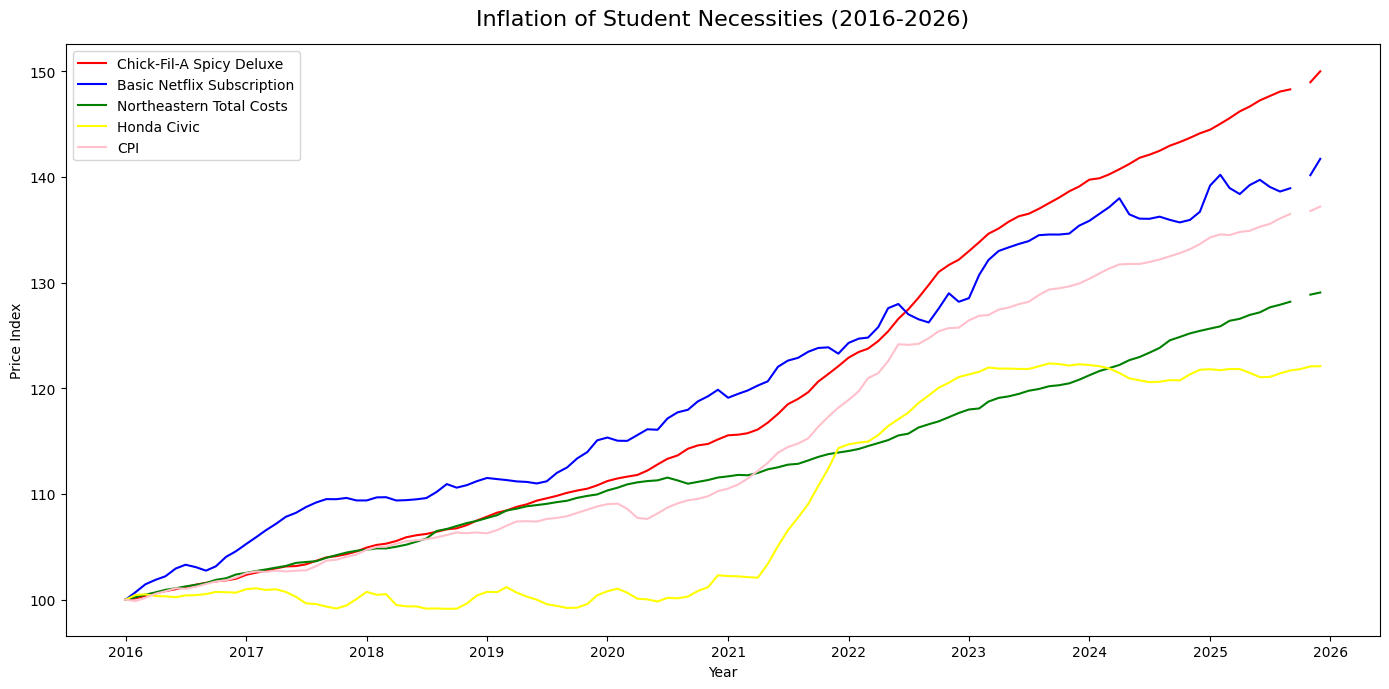

In [120]:
from matplotlib.lines import lineStyles

df = df.loc["2016":"2026"]
base_2016 = df.loc["2016"].iloc[0]
df_indexed = (df / base_2016) * 100

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_indexed.index, df_indexed['Chick-Fil-A Spicy Deluxe'], linestyle='-', color='red', label='Chick-Fil-A Spicy Deluxe')
ax.plot(df_indexed.index, df_indexed['Basic Netflix Subscription'], linestyle='-',  color='blue', label='Basic Netflix Subscription')
ax.plot(df_indexed.index, df_indexed['Northeastern Total Costs'], linestyle='-', color= 'green', label='Northeastern Total Costs')
ax.plot(df_indexed.index, df_indexed['Honda Civic'], linestyle='-', color='yellow', label='Honda Civic')
ax.plot(df_indexed.index, df_indexed['CPI'], linestyle='-', color='pink', label='CPI')

ax.set_title('Inflation of Student Necessities (2016-2026)', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Price Index')

ax.legend()
plt.tight_layout()
plt.show()



In [121]:
student_SPI_weights = {
    'food': 0.3,
    'tuition': 0.4,
    'car': 0.25,
    'streaming': 0.05
}

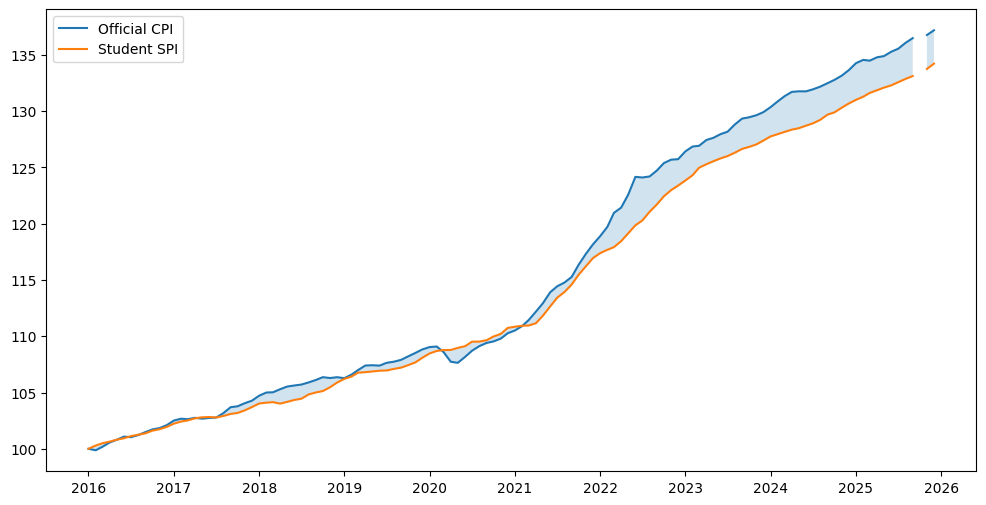

In [122]:
df_indexed["Student_SPI"] = (
    student_SPI_weights['food']      * df_indexed['Chick-Fil-A Spicy Deluxe'] +
    student_SPI_weights['tuition']   * df_indexed['Northeastern Total Costs'] +
    student_SPI_weights['car']       * df_indexed['Honda Civic'] +
    student_SPI_weights['streaming'] * df_indexed['Basic Netflix Subscription']
)

plt.figure(figsize=(12, 6))
plt.plot(df_indexed.index, df_indexed["CPI"], label="Official CPI")
plt.plot(df_indexed.index, df_indexed["Student_SPI"], label="Student SPI")
plt.fill_between(df_indexed.index, df_indexed["Student_SPI"], df_indexed["CPI"], alpha=0.2)
plt.legend()
plt.show()

In [123]:
df_RAW = pd.DataFrame({'CPI Tuition': tuition, 'CPI Streaming': streaming})

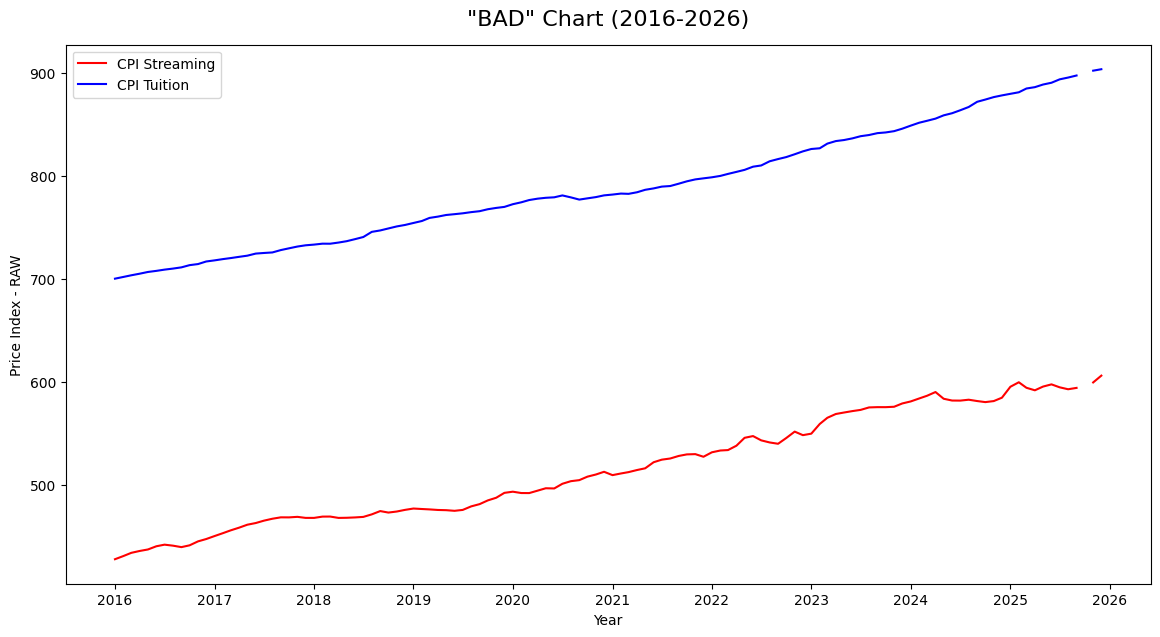

In [124]:
df_RAW = df_RAW.loc["2016":"2026"]

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_RAW.index, df_RAW['CPI Streaming'], linestyle='-', color='red', label='CPI Streaming')
ax.plot(df_RAW.index, df_RAW['CPI Tuition'], linestyle='-', color='blue', label='CPI Tuition')
ax.set_title('"BAD" Chart (2016-2026)', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Price Index - RAW')

ax.legend()
plt.show()

✓ Successfully fetched Boston CPI data from FRED

✓ DataFrame updated with:
  - Official_CPI (re-indexed to Jan 2016 = 100)
  - Boston_CPI (re-indexed to Jan 2016 = 100)
  - Student_SPI (average of student costs, re-indexed to Jan 2016 = 100)


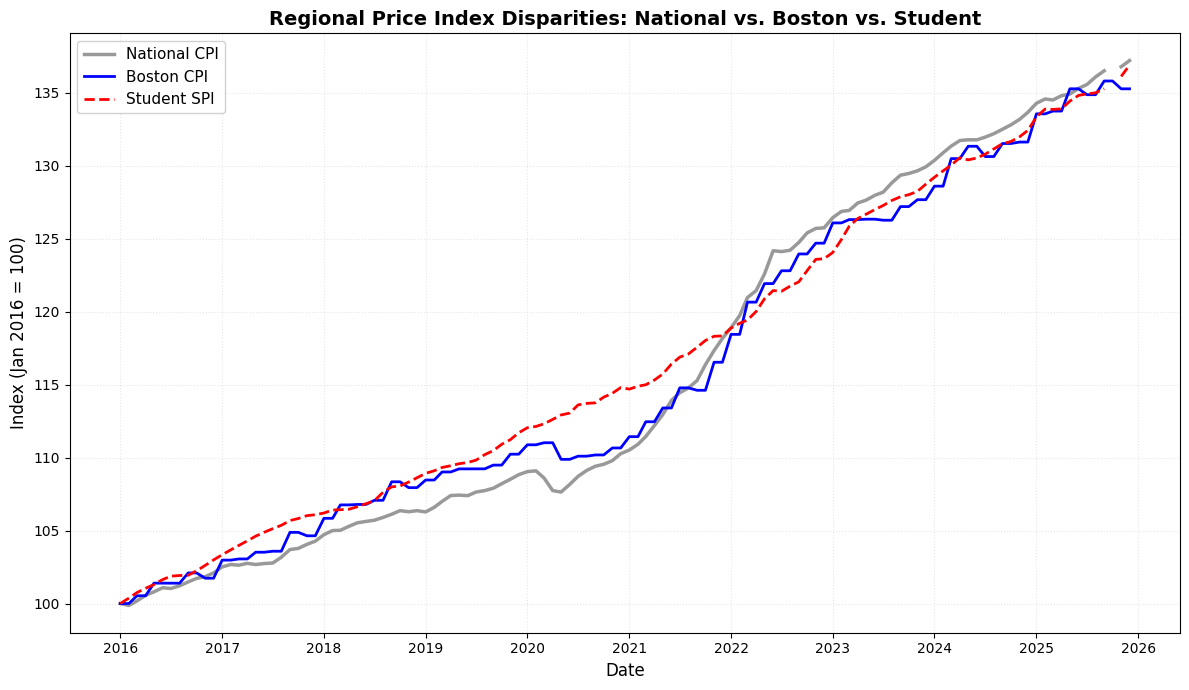


MACROECONOMIC ANALYSIS: REGIONAL PRICE DISPARITIES

Latest Index Values (as of December 2025):
  National CPI:       137.19
  Boston CPI:         135.25
  Student SPI:        136.87

Cumulative Growth Since Jan 2016:
  National CPI:       37.19%
  Boston CPI:         35.25%
  Student SPI:        36.87%

------------------------------------------------------------
KEY DISPARITIES:
------------------------------------------------------------
  Student Burden (Student vs National):      -0.31 points
  Regional Disparity (Boston vs National):   -1.93 points
  Student Premium (Student vs Boston):       +1.62 points

Annualized Inflation Rates (9.9 years):
  National CPI:       3.24% per year
  Boston CPI:         3.09% per year
  Student SPI:        3.22% per year


In [125]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
from datetime import datetime

# Initialize FRED API
# Get a free API key from: https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = '82078b7e0f65bcf75cbf64afe01471d7'  # Replace with your key

# FRED series code for Boston-Cambridge-Newton CPI
# CUURA103SA0 = Consumer Price Index for All Urban Consumers: All Items in Boston-Cambridge-Newton
boston_cpi_code = 'CUURA103SA0'

try:
    # Attempt to fetch Boston CPI data
    fred = Fred(api_key=FRED_API_KEY)
    boston_cpi = fred.get_series(boston_cpi_code)

    # Convert to DataFrame
    boston_df = pd.DataFrame(boston_cpi, columns=['Boston_CPI_Raw'])

    # Define the base date for re-indexing
    base_date = pd.Timestamp('2016-01-01')

    # Get the value at the base date
    if base_date in boston_df.index:
        base_value = boston_df.loc[base_date, 'Boston_CPI_Raw']
    else:
        # Find the closest date to Jan 1, 2016
        closest_date = boston_df.index[boston_df.index.get_indexer([base_date], method='nearest')[0]]
        base_value = boston_df.loc[closest_date, 'Boston_CPI_Raw']
        print(f"Note: Using {closest_date.date()} as base date (closest to 2016-01-01)")

    # Re-index to 100 on Jan 1, 2016
    boston_df['Boston_CPI'] = (boston_df['Boston_CPI_Raw'] / base_value) * 100

    # Remove duplicate Boston_CPI columns if they exist
    cols_to_drop = [col for col in df.columns if 'Boston_CPI' in col]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)

    # Merge with existing df
    df = df.merge(boston_df[['Boston_CPI']], left_index=True, right_index=True, how='left')

    # Handle missing values through forward fill
    df['Boston_CPI'] = df['Boston_CPI'].ffill()

    boston_data_available = True
    print("✓ Successfully fetched Boston CPI data from FRED")

except Exception as e:
    print(f"⚠️  Could not fetch Boston CPI data: {e}")
    print("Proceeding with National CPI vs Student SPI comparison only...")

    # Remove any existing Boston_CPI columns
    cols_to_drop = [col for col in df.columns if 'Boston_CPI' in col]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)

    boston_data_available = False

# Create Student SPI as average of student-relevant items (re-indexed to Jan 2016 = 100)
# Using: Chick-Fil-A, Netflix, and Northeastern costs
student_items = ['Chick-Fil-A Spicy Deluxe', 'Basic Netflix Subscription', 'Northeastern Total Costs']

# Calculate the average of these items
df['Student_SPI_Raw'] = df[student_items].mean(axis=1)

# Re-index Student SPI to 100 on Jan 1, 2016
base_student_value = df.loc['2016-01-01', 'Student_SPI_Raw']
df['Student_SPI'] = (df['Student_SPI_Raw'] / base_student_value) * 100

# Also re-index CPI to 100 on Jan 1, 2016 for consistency
base_cpi_value = df.loc['2016-01-01', 'CPI']
df['Official_CPI'] = (df['CPI'] / base_cpi_value) * 100

print(f"\n✓ DataFrame updated with:")
print(f"  - Official_CPI (re-indexed to Jan 2016 = 100)")
if boston_data_available:
    print(f"  - Boston_CPI (re-indexed to Jan 2016 = 100)")
print(f"  - Student_SPI (average of student costs, re-indexed to Jan 2016 = 100)")

# Create the comparison plot
plt.figure(figsize=(12, 7))

plt.plot(df.index, df['Official_CPI'], color='grey', linewidth=2.5, label='National CPI', alpha=0.8)

if boston_data_available:
    plt.plot(df.index, df['Boston_CPI'], color='blue', linewidth=2, label='Boston CPI')

plt.plot(df.index, df['Student_SPI'], color='red', linewidth=2, label='Student SPI', linestyle='--')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Index (Jan 2016 = 100)', fontsize=12)

if boston_data_available:
    plt.title('Regional Price Index Disparities: National vs. Boston vs. Student', fontsize=14, fontweight='bold')
else:
    plt.title('Price Index Comparison: National CPI vs. Student SPI', fontsize=14, fontweight='bold')

plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()

plt.show()

# Print summary statistics for macroeconomic analysis
print("\n" + "="*60)
print("MACROECONOMIC ANALYSIS: REGIONAL PRICE DISPARITIES")
print("="*60)

print(f"\nLatest Index Values (as of {df.index[-1].strftime('%B %Y')}):")
print(f"  National CPI:      {df['Official_CPI'].iloc[-1]:>7.2f}")
if boston_data_available:
    print(f"  Boston CPI:        {df['Boston_CPI'].iloc[-1]:>7.2f}")
print(f"  Student SPI:       {df['Student_SPI'].iloc[-1]:>7.2f}")

print(f"\nCumulative Growth Since Jan 2016:")
national_growth = df['Official_CPI'].iloc[-1] - 100
student_growth = df['Student_SPI'].iloc[-1] - 100

print(f"  National CPI:      {national_growth:>6.2f}%")
if boston_data_available:
    boston_growth = df['Boston_CPI'].iloc[-1] - 100
    print(f"  Boston CPI:        {boston_growth:>6.2f}%")
print(f"  Student SPI:       {student_growth:>6.2f}%")

print(f"\n" + "-"*60)
print("KEY DISPARITIES:")
print("-"*60)

student_burden = df['Student_SPI'].iloc[-1] - df['Official_CPI'].iloc[-1]
print(f"  Student Burden (Student vs National):     {student_burden:>+6.2f} points")

if boston_data_available:
    regional_gap = df['Boston_CPI'].iloc[-1] - df['Official_CPI'].iloc[-1]
    print(f"  Regional Disparity (Boston vs National):  {regional_gap:>+6.2f} points")
    print(f"  Student Premium (Student vs Boston):      {df['Student_SPI'].iloc[-1] - df['Boston_CPI'].iloc[-1]:>+6.2f} points")

# Calculate annualized growth rates
months = len(df) - 1
years = months / 12
ann_national = ((df['Official_CPI'].iloc[-1] / 100) ** (1/years) - 1) * 100
ann_student = ((df['Student_SPI'].iloc[-1] / 100) ** (1/years) - 1) * 100

print(f"\nAnnualized Inflation Rates ({years:.1f} years):")
print(f"  National CPI:      {ann_national:>5.2f}% per year")
if boston_data_available:
    ann_boston = ((df['Boston_CPI'].iloc[-1] / 100) ** (1/years) - 1) * 100
    print(f"  Boston CPI:        {ann_boston:>5.2f}% per year")
print(f"  Student SPI:       {ann_student:>5.2f}% per year")

print("="*60)

if not boston_data_available:
    print(f"\n💡 To add Boston CPI data:")
    print(f"   1. Get a free FRED API key: https://fred.stlouisfed.org/docs/api/api_key.html")
    print(f"   2. Replace 'YOUR_FRED_API_KEY_HERE' with your key")
    print(f"   3. Re-run the code")